In [1]:
# Local Jupyter setup version — resnet18
# Put iivp-2026-challenge.zip in the same folder as this notebook, then run cells from top to bottom.
# This version keeps the same data loading / prints as your EfficientNet notebook, but uses resnet18.

from pathlib import Path
import os
import zipfile
import numpy as np
import pandas as pd

MODEL_NAME = "resnet18"

NOTEBOOK_DIR = Path.cwd()
ZIP_PATH = NOTEBOOK_DIR / "iivp-2026-challenge.zip"
EXTRACT_DIR = NOTEBOOK_DIR / "data"
MODEL_PATH = NOTEBOOK_DIR / f"best_model_{MODEL_NAME}.pth"
SUBMISSION_PATH = NOTEBOOK_DIR / f"submission_{MODEL_NAME}.csv"

print("Notebook folder:", NOTEBOOK_DIR)
print("Zip exists:", ZIP_PATH.exists(), "->", ZIP_PATH)
print("Model:", MODEL_NAME)
print("Model save path:", MODEL_PATH)
print("Submission save path:", SUBMISSION_PATH)


Notebook folder: C:\Users\samue
Zip exists: True -> C:\Users\samue\iivp-2026-challenge.zip
Model: resnet18
Model save path: C:\Users\samue\best_model_resnet18.pth
Submission save path: C:\Users\samue\submission_resnet18.csv


In [2]:
# Extract the competition zip locally.
# This replaces the Kaggle CLI download commands, which do not work unless Kaggle CLI is installed/configured.

if not ZIP_PATH.exists():
    raise FileNotFoundError(
        f"Could not find {ZIP_PATH.name} in {NOTEBOOK_DIR}. "
        "Move iivp-2026-challenge.zip into the same folder as this notebook and run again."
    )

EXTRACT_DIR.mkdir(exist_ok=True)

# Only extract if train.csv/test.csv are not already present somewhere under data/
train_csvs = list(EXTRACT_DIR.rglob("train.csv"))
test_csvs = list(EXTRACT_DIR.rglob("test.csv"))

if not train_csvs or not test_csvs:
    print("Extracting zip...")
    with zipfile.ZipFile(ZIP_PATH, "r") as zip_ref:
        zip_ref.extractall(EXTRACT_DIR)
else:
    print("Data already extracted; skipping unzip.")

# Locate CSV files even if the zip created an extra nested folder
train_csvs = list(EXTRACT_DIR.rglob("train.csv"))
test_csvs = list(EXTRACT_DIR.rglob("test.csv"))

if not train_csvs or not test_csvs:
    raise FileNotFoundError("Could not find train.csv and/or test.csv after extraction. Check the zip contents.")

TRAIN_CSV = train_csvs[0]
TEST_CSV = test_csvs[0]
DATA_DIR = TRAIN_CSV.parent

print("DATA_DIR:", DATA_DIR)
print("TRAIN_CSV:", TRAIN_CSV)
print("TEST_CSV:", TEST_CSV)


Data already extracted; skipping unzip.
DATA_DIR: C:\Users\samue\data
TRAIN_CSV: C:\Users\samue\data\train.csv
TEST_CSV: C:\Users\samue\data\test.csv


In [3]:
# Quick folder check
for dirname, _, filenames in os.walk(DATA_DIR):
    print(f"Found directory: {dirname}")
    if filenames:
        print(f"Sample files: {filenames[:5]}")


Found directory: C:\Users\samue\data
Sample files: ['sample_submission.csv', 'test.csv', 'train.csv']
Found directory: C:\Users\samue\data\test
Found directory: C:\Users\samue\data\test\test
Sample files: ['10002.png', '10015.png', '10021.png', '10037.png', '10040.png']
Found directory: C:\Users\samue\data\train
Found directory: C:\Users\samue\data\train\train
Found directory: C:\Users\samue\data\train\train\0
Sample files: ['103265.png', '103266.png', '103267.png', '103268.png', '103269.png']
Found directory: C:\Users\samue\data\train\train\1
Sample files: ['12397.png', '12398.png', '12399.png', '12400.png', '12401.png']
Found directory: C:\Users\samue\data\train\train\2
Sample files: ['12524.png', '12525.png', '12526.png', '12527.png', '12528.png']
Found directory: C:\Users\samue\data\train\train\3
Sample files: ['12590.png', '12591.png', '12592.png', '12593.png', '12595.png']
Found directory: C:\Users\samue\data\train\train\4
Sample files: ['103741.png', '103742.png', '103743.png', 

In [4]:
print("Current notebook folder files:")
print(os.listdir(NOTEBOOK_DIR))

print("\nExtracted data folder files:")
print(os.listdir(DATA_DIR))


Current notebook folder files:
['.anaconda', '.android', '.arduinoIDE', '.cache', '.conda', '.condarc', '.continuum', '.ftb', '.gitconfig', '.gradle', '.idea', '.idlerc', '.ipynb_checkpoints', '.ipython', '.jdks', '.jupyter', '.lesshst', '.m2', '.matplotlib', '.Neo4jDesktop2', '.openjfx', '.Protege', '.viminfo', '.vscode', 'aae_dim_reduc_2.png', 'anaconda3', 'anaconda_projects', 'ANEW_Valence_per_word.tsv', 'AppData', 'Application Data', 'best_model_resnet18.pth', 'clinic1.zip', 'clinic3_empty (2).ipynb', 'clinic3_empty (3).ipynb', 'clinic3_empty.ipynb', 'clinic4-dr (1).ipynb', 'clinic4-dr.ipynb', 'clinic5-ts.ipynb', 'codebook.txt', 'colombia_2020-05-28.csv', 'Contacts', 'Cookies', 'CurrentGrades2 (1).csv', 'CurrentGrades2.csv', 'curseforge', 'DA-clinic1-empty (1).ipynb', 'DA-clinic1-empty (2).ipynb', 'DA-clinic1-empty.ipynb', 'DA-clinic1-emptyTEST.ipynb', 'DA-clinic1-final', 'DA-clinic1-final,ipynb', 'DA-clinic1-final.ipynb', 'DA-clinic2 (1).ipynb', 'DA-clinic2.ipynb', 'DA-clinic2_fin

In [5]:
# No Kaggle path needed here. Data was extracted in the earlier cell.
print("Ready to load data from:", DATA_DIR)


Ready to load data from: C:\Users\samue\data


In [6]:
print(os.listdir(DATA_DIR))


['sample_submission.csv', 'test', 'test.csv', 'train', 'train.csv']


In [7]:
train_df = pd.read_csv(TRAIN_CSV)
test_df  = pd.read_csv(TEST_CSV)

print(train_df.head(10))
print(f"\nTrain size: {len(train_df)}")
print(f"Test size:  {len(test_df)}")
print(f"\nTrain columns: {train_df.columns.tolist()}")
print(f"Test columns:  {test_df.columns.tolist()}")


      Id  Category
0   7168         6
1   9876         3
2  78117         6
3   9626         1
4  29492         3
5  76947         2
6  40828         4
7  56277         2
8   7414         9
9   5468         5

Train size: 17000
Test size:  3000

Train columns: ['Id', 'Category']
Test columns:  ['Id']


In [8]:
# Find image folders locally. This handles both train/train/... and train/... layouts.
TRAIN_IMG_DIR = DATA_DIR / "train" / "train"
if not TRAIN_IMG_DIR.exists():
    TRAIN_IMG_DIR = DATA_DIR / "train"

TEST_IMG_DIR = DATA_DIR / "test" / "test"
if not TEST_IMG_DIR.exists():
    TEST_IMG_DIR = DATA_DIR / "test"

print("TRAIN_IMG_DIR:", TRAIN_IMG_DIR)
print("TEST_IMG_DIR:", TEST_IMG_DIR)

# Check image folder contents
print(os.listdir(TRAIN_IMG_DIR / "0")[:10])
print(os.listdir(TEST_IMG_DIR)[:10])


TRAIN_IMG_DIR: C:\Users\samue\data\train\train
TEST_IMG_DIR: C:\Users\samue\data\test\test
['103265.png', '103266.png', '103267.png', '103268.png', '103269.png', '103270.png', '103271.png', '103272.png', '103273.png', '103274.png']
['10002.png', '10015.png', '10021.png', '10037.png', '10040.png', '10041.png', '10045.png', '10046.png', '10056.png', '10058.png']


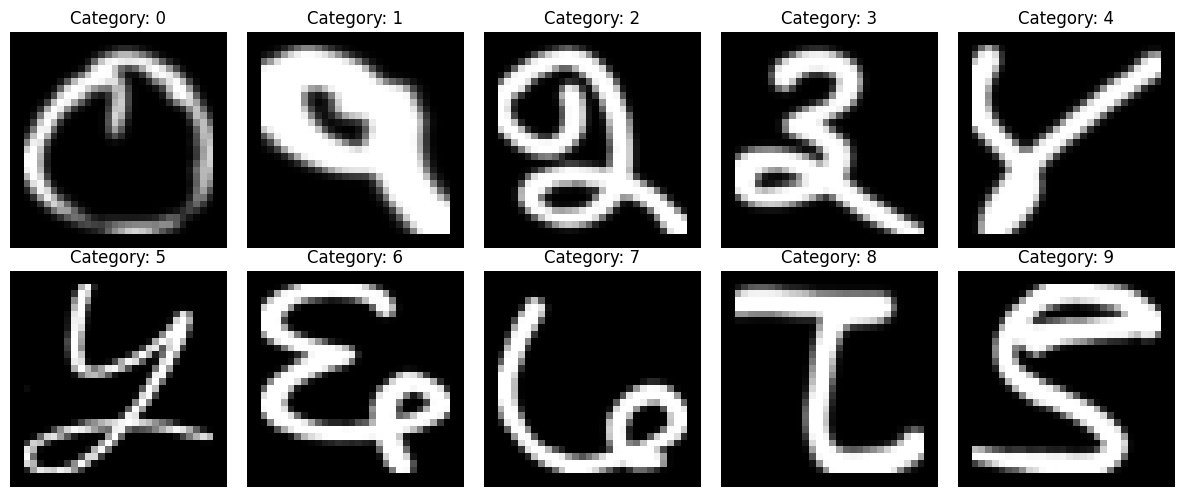

Image size: (32, 32)
Image mode: L
Categories found: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]


In [9]:
import matplotlib.pyplot as plt
from PIL import Image
import math

# Show one example image for every category found in train.csv
categories = sorted(train_df["Category"].unique())
cols = 5
rows = math.ceil(len(categories) / cols)

fig, axes = plt.subplots(rows, cols, figsize=(12, 2.5 * rows))
axes = np.array(axes).reshape(-1)

for ax, digit in zip(axes, categories):
    sample = train_df[train_df['Category'] == digit].iloc[0]
    img = Image.open(TRAIN_IMG_DIR / str(digit) / f"{sample['Id']}.png")
    ax.imshow(img, cmap='gray')
    ax.set_title(f"Category: {digit}")
    ax.axis('off')

for ax in axes[len(categories):]:
    ax.axis('off')

plt.tight_layout()
plt.show()

sample = train_df.iloc[0]
sample_img = Image.open(TRAIN_IMG_DIR / str(sample['Category']) / f"{sample['Id']}.png")
print(f"Image size: {sample_img.size}")
print(f"Image mode: {sample_img.mode}")
print(f"Categories found: {categories}")


In [10]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from sklearn.model_selection import train_test_split
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
from PIL import Image

# --- Dataset ---
class DigitDataset(Dataset):
    def __init__(self, df, img_dir, transform=None, has_labels=True):
        self.df = df.reset_index(drop=True)
        self.img_dir = img_dir
        self.transform = transform
        self.has_labels = has_labels

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        if self.has_labels:
            img_path = f"{self.img_dir}/{row['Category']}/{row['Id']}.png"
        else:
            img_path = f"{self.img_dir}/{row['Id']}.png"

        # Keep images grayscale. The pretrained ResNet first layer is adapted from RGB to 1 channel below.
        img = Image.open(img_path).convert('L')

        if self.transform:
            img = self.transform(img)

        if self.has_labels:
            return img, int(row['Category'])
        return img, row['Id']

# --- Transforms ---
transform_train = transforms.Compose([
    transforms.RandomRotation(10),
    transforms.RandomAffine(0, translate=(0.1, 0.1)),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

transform_val = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# --- Split ---
train_split, val_split = train_test_split(
    train_df, test_size=0.2, stratify=train_df['Category'], random_state=42
)

train_dataset = DigitDataset(train_split, TRAIN_IMG_DIR, transform_train)
val_dataset   = DigitDataset(val_split,   TRAIN_IMG_DIR, transform_val)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_dataset,   batch_size=64, shuffle=False, num_workers=0)

# --- Model ---
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
print(f"Using model: {MODEL_NAME}")

def build_resnet(model_name="resnet18", num_classes=10):
    """
    Builds a pretrained ResNet and adapts it for 1-channel grayscale digit images.
    The original RGB conv1 weights are averaged into a single grayscale channel,
    so we still benefit from ImageNet pretraining.
    """
    model_name = model_name.lower()

    if model_name == "resnet18":
        try:
            weights = models.ResNet18_Weights.DEFAULT
            model = models.resnet18(weights=weights)
        except AttributeError:
            model = models.resnet18(pretrained=True)
    elif model_name == "resnet50":
        try:
            weights = models.ResNet50_Weights.DEFAULT
            model = models.resnet50(weights=weights)
        except AttributeError:
            model = models.resnet50(pretrained=True)
    else:
        raise ValueError("MODEL_NAME must be either 'resnet18' or 'resnet50'.")

    # Convert first convolution from 3 input channels to 1 input channel
    old_conv = model.conv1
    model.conv1 = nn.Conv2d(
        in_channels=1,
        out_channels=old_conv.out_channels,
        kernel_size=old_conv.kernel_size,
        stride=old_conv.stride,
        padding=old_conv.padding,
        bias=False
    )

    with torch.no_grad():
        model.conv1.weight.copy_(old_conv.weight.mean(dim=1, keepdim=True))

    # Replace final classification layer
    model.fc = nn.Linear(model.fc.in_features, num_classes)

    return model

model = build_resnet(MODEL_NAME, num_classes=10).to(device)

# --- Training ---
optimizer = AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = CosineAnnealingLR(optimizer, T_max=20)
criterion = nn.CrossEntropyLoss()

best_acc = 0
EPOCHS = 1

for epoch in range(EPOCHS):
    # Train
    model.train()
    running_loss = 0.0

    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * imgs.size(0)

    scheduler.step()

    # Validate
    model.eval()
    correct = 0

    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            preds = model(imgs).argmax(dim=1)
            correct += (preds == labels).sum().item()

    train_loss = running_loss / len(train_split)
    acc = correct / len(val_split)

    print(f"Epoch {epoch+1:02d}/{EPOCHS} — Train Loss: {train_loss:.4f} — Val Acc: {acc:.4f}")

    if acc > best_acc:
        best_acc = acc
        torch.save(model.state_dict(), MODEL_PATH)
        print(f"  Saved new best model to {MODEL_PATH}")

print(f"\nBest Val Accuracy: {best_acc:.4f}")


Using device: cpu
Using model: resnet18
Epoch 01/1 — Train Loss: 0.0733 — Val Acc: 0.9771
  Saved new best model to C:\Users\samue\best_model_resnet18.pth

Best Val Accuracy: 0.9771


In [11]:
import glob

# Build a lookup: Id -> file path for test images
test_files = glob.glob(str(TEST_IMG_DIR / "**" / "*.png"), recursive=True)
test_lookup = {os.path.splitext(os.path.basename(f))[0]: f for f in test_files}
print(f"Found {len(test_lookup)} test image files")

# Dataset for test images
class TestDataset(Dataset):
    def __init__(self, df, lookup, transform):
        self.df = df.reset_index(drop=True)
        self.lookup = lookup
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        key = str(row['Id'])
        if key not in self.lookup:
            raise FileNotFoundError(f"Could not find test image for Id={key}")
        img = Image.open(self.lookup[key]).convert('L')
        if self.transform:
            img = self.transform(img)
        return img, row['Id']

test_dataset = TestDataset(test_df, test_lookup, transform_val)
test_loader  = DataLoader(test_dataset, batch_size=64, shuffle=False, num_workers=0)

print(f"Predicting test set with {MODEL_NAME}")

# Load best model and predict
model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
model.eval()

ids, preds = [], []
with torch.no_grad():
    for imgs, file_ids in test_loader:
        imgs = imgs.to(device)
        outputs = model(imgs).argmax(dim=1).cpu().numpy()
        ids.extend(file_ids.numpy() if hasattr(file_ids, "numpy") else list(file_ids))
        preds.extend(outputs)

# Save submission
submission = pd.DataFrame({'Id': ids, 'Category': preds})
submission.to_csv(SUBMISSION_PATH, index=False)
print(f"Submission saved to: {SUBMISSION_PATH}")
print(f"Shape: {submission.shape}")
print(submission.head(10))


Found 3000 test image files
Predicting test set with resnet18
Submission saved to: C:\Users\samue\submission_resnet18.csv
Shape: (3000, 2)
      Id  Category
0  56604         6
1  29396         3
2  43803         6
3  12313         0
4  10341         8
5  40355         8
6  41117         4
7  71324         7
8   6854         1
9  12761         8
